/tmp/ipykernel_4384/468493981.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn")


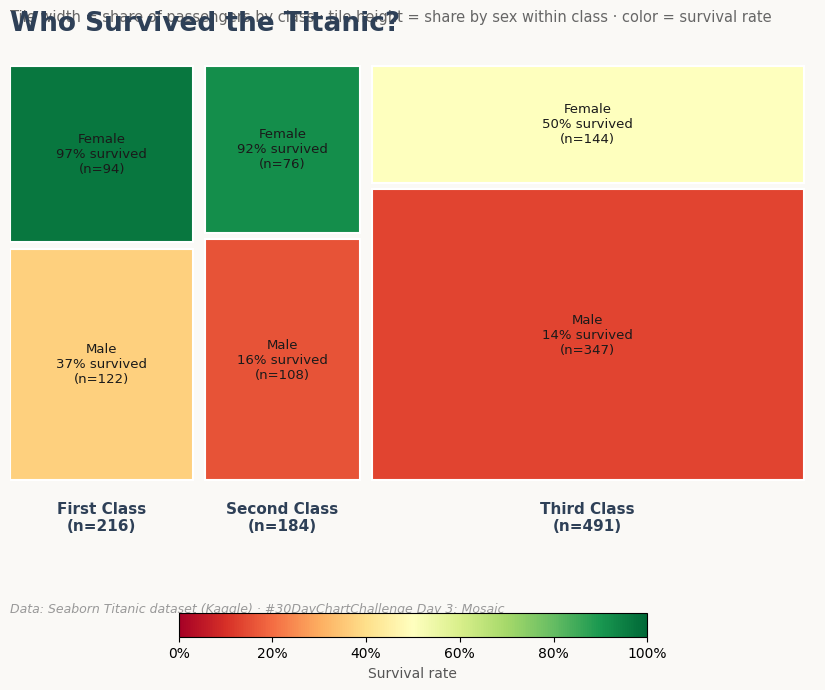

In [1]:
"""
#30DayChartChallenge — Day 3: Mosaic
"Who survived the Titanic?" — a mosaic plot of passenger class x sex,
colored by survival rate.

Data source (loaded live, no hardcoded values):
Seaborn's Titanic dataset (the canonical open copy used in countless
tutorials, originally from Kaggle's Titanic competition)
https://github.com/mwaskom/seaborn-data

Mosaic plots show two (or more) categorical variables at once: tile WIDTH
encodes one variable's share of the total, tile HEIGHT encodes the second
variable's share *within* that column, and here tile COLOR encodes a third
value (survival rate) on top of that.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ---------------------------------------------------------------------------
# 1. CONFIG
# ---------------------------------------------------------------------------
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
GAP = 0.015  # gap between tiles, as a fraction of the plot

# ---------------------------------------------------------------------------
# 2. LOAD DATA DIRECTLY FROM SOURCE
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_URL)
df = df.dropna(subset=["class", "sex", "survived"])

# Order classes naturally rather than alphabetically
class_order = [c for c in ["First", "Second", "Third"] if c in df["class"].unique()]
sex_order = ["male", "female"]

# ---------------------------------------------------------------------------
# 3. BUILD THE CROSS-TABULATION NEEDED FOR THE MOSAIC
# ---------------------------------------------------------------------------
total_n = len(df)

# Column (x) widths: share of total passengers in each class
class_counts = df["class"].value_counts().reindex(class_order)
class_widths = (class_counts / total_n).to_dict()

# Within each class, row (y) heights: share of that class by sex,
# and the survival rate (used for color) for each class x sex cell.
cell_info = {}
for cls in class_order:
    sub = df[df["class"] == cls]
    n_cls = len(sub)
    y_cursor = 0.0
    rows = []
    for sex in sex_order:
        sex_sub = sub[sub["sex"] == sex]
        n_sex = len(sex_sub)
        if n_sex == 0:
            continue
        height = n_sex / n_cls
        survival_rate = sex_sub["survived"].mean()
        rows.append({
            "sex": sex,
            "n": n_sex,
            "height": height,
            "y0": y_cursor,
            "survival_rate": survival_rate,
        })
        y_cursor += height
    cell_info[cls] = rows

# ---------------------------------------------------------------------------
# 4. PLOT — mosaic of rectangles
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7), facecolor="#FAF9F6")
ax.set_facecolor("#FAF9F6")

cmap = cm.get_cmap("RdYlGn")
norm = mcolors.Normalize(vmin=0, vmax=1)

x_cursor = 0.0
for cls in class_order:
    width = class_widths[cls] - GAP
    for row in cell_info[cls]:
        height = row["height"] - GAP
        color = cmap(norm(row["survival_rate"]))
        rect = patches.Rectangle(
            (x_cursor, row["y0"]), width, height,
            facecolor=color, edgecolor="white", linewidth=1.5,
        )
        ax.add_patch(rect)

        # Label: sex + survival % + n, centered in the tile
        cx = x_cursor + width / 2
        cy = row["y0"] + height / 2
        ax.text(
            cx, cy,
            f"{row['sex'].capitalize()}\n{row['survival_rate']*100:.0f}% survived\n(n={row['n']})",
            ha="center", va="center", fontsize=9.5, color="#1a1a1a", fontweight="medium",
        )

    # Class label below the x-axis
    ax.text(
        x_cursor + width / 2, -0.05, f"{cls} Class\n(n={class_counts[cls]})",
        ha="center", va="top", fontsize=11, fontweight="bold", color="#2E4057",
    )
    x_cursor += class_widths[cls]

ax.set_xlim(0, 1)
ax.set_ylim(-0.15, 1.02)
ax.axis("off")

ax.set_title(
    "Who Survived the Titanic?",
    fontsize=19, fontweight="bold", color="#2E4057", pad=15, loc="left",
)
ax.text(
    0, 1.06, "Tile width = share of passengers by class · tile height = share by sex within class · color = survival rate",
    fontsize=10.5, color="#666666", ha="left", transform=ax.transAxes,
)

# Colorbar legend for survival rate
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.04, pad=0.12)
cbar.set_label("Survival rate", fontsize=10, color="#555555")
cbar.ax.xaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")

ax.text(
    0, -0.14, "Data: Seaborn Titanic dataset (Kaggle) · #30DayChartChallenge Day 3: Mosaic",
    fontsize=9, color="#999999", ha="left", transform=ax.transAxes, style="italic",
)

plt.tight_layout()
plt.savefig("day3_mosaic.png", dpi=200, facecolor="#FAF9F6", bbox_inches="tight")
plt.show()